In [27]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from scipy.stats import pearsonr
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars_bin/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path
y2sec=-365.25*24*3600
factor = y2sec/10**12 #kg/s to GT/yr

variable2 = 'shelfmelt'

pth = pth_imip6hack

variable1 = 'shelfmelt'


pth1 = pth_helene

# variable2 = 'iareafl'
# factor = 1
# pth = pth_helene

# variable2 = 'iareagr'
# factor = 1
# pth = pth_helene


# variable2 = 'dslc_anom'
# factor = -1
# pth = pth_imip6hack

fpath = f'./figs/{variable2}_depthbin/'
fname = f'{variable2}_'

In [28]:

 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = [] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
for i in range(1,19):
    df['sector_'+str(i)]=0
df['AIS']=0
df_org = df.copy()
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)                 
df_info_model = df_info[df_info['fileID']==df.iloc[i].Model ]
df_info_model_exp = df_info_model[df_info_model['Experiment']==exp]

df_best = pd.read_csv('tables/best_ms_method_per_model.csv')
df_cumBMB2300 = pd.read_csv('./tables/cumulative_shelfmelt_2300.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')

for df_ms in [df_cumBMB2300,df_dslr2300]:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    
    df_ms['Aurora']=df_ms['sector_8']
    df_ms ['Wilkes']=df_ms['sector_7']
    
df_cumBMB2300['Filchner_Ronne'] = df_cumBMB2300['FilchnerRonne']
regions = ['AIS',
 'Amundsen',
 'Ross',
 'FilchnerRonne',
           'Aurora',
           'Wilkes'
    ]
regions_keys ={}
regions_keys['AIS'] = ['']

regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['Filchner_Ronne']= ['_sector_5','_sector_11']
regions_keys['Aurora']= ['_sector_8']
regions_keys['Wilkes']= ['_sector_7']



In [29]:
dfs = [

   df_dslr2300]
regions_extra=[ 'Amundsen',
 'Ross',
 'Filchner_Ronne']
for df in dfs:
    for key in regions_extra:
        y = 0
        for sectors in regions_keys[key]:
        
            y =y + df[sectors[1:]]
        df[key]=y

In [30]:
dic_area_of_interest ={}
dic_area_of_interest['AIS']= ['']
# dic_area_of_interest['WestAntarctica'] = ['_region_1']
# dic_area_of_interest['EastAntarctica'] = ['_region_2']
# dic_area_of_interest['Peninsula'] = ['_region_3']
dic_area_of_interest['Amundsen'] = ['_sector_4']
dic_area_of_interest['Filchner_Ronne'] = ['_sector_5','_sector_11']
dic_area_of_interest['Ross'] = ['_sector_2','_sector_6']
dic_area_of_interest['Aurora'] = ['_sector_8']
dic_area_of_interest['Wilkes'] = ['_sector_7']

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3' 

In [31]:
dic_corr_region={}
dic_cum_region={}
depths = np.array([  -30.,   -90.,  -150.,  -210.,  -270.,  -330.,  -390.,  -450.,  -510.,
        -570.,  -630.,  -690.,  -750.,  -810.,  -870.,  -930.,  -990., -1050.,
       -1110., -1170., -1230., -1290., -1350., -1410., -1470., -1530., -1590.,
       -1650., -1710., -1770.])

In [32]:
if os.path.exists(fpath):
    print( f"The path '{fpath}' already exists.")
else:
    os.makedirs(fpath)
    print( f"The path '{fpath}' did not exist, so it has been created.")
dic_region_cum ={}
dic_region_corr ={}

for key in dic_area_of_interest.keys():
  
    lst = dic_area_of_interest[key]

    a4_width = 8.27  # inches
    a4_height = 11.69
    colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
    fs = 8
    regionnumbers = [2,6]
    df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
    
    dic_exp_cum ={}
    dic_exp_corr ={}
    
    for j,exp in enumerate(expnames):
        df = df_org[df_org['Experiment']== exp].reset_index(drop=True)
        dic_model_cum = {}
        dic_model_corr ={}
        for i in range (df.shape[0]):
            ix =i //2
            iy=i%2
            pth_way = df.iloc[i].Path
            #get shelf area

#             pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
            pth_var1 = f'{pth1}/{df.iloc[i].Experiment}/{variable1}/computed_{variable1}_AIS_{df.iloc[i].Model}_{df.iloc[i].Experiment}.nc'
  
            if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
            else:
                nmname = df.iloc[i].Model
#             pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            pth_tf = f'{pth}/{df.iloc[i].Experiment}/{variable2}/computed_{variable2}_AIS_{nmname}_{df.iloc[i].Experiment}.nc'
            
   
       
            d3 = xr.open_dataset(pth_tf,decode_times=False )
            d1 = xr.open_dataset(pth_var1,decode_times=False )
        
        


            tmin = np.min([d3.time.size])
            y_corr_depth =[]
            y_cum_depth =[]
            
            for l,depth in enumerate(depths):#itera thorught depth
                #melting per area
                the_ys = np.zeros((len(dic_area_of_interest[key]),tmin))
                the_ys_var1 = np.zeros((len(dic_area_of_interest[key]),tmin))
            
          
                for k,nm in enumerate(lst):
                    #from bottom until depth line
                    the_ys[k,:]= d3[f'{variable2}{nm}'].values[l:-1,:tmin].sum(axis=0)*factor 
                    #totle shlefmelt helene (does not change)
                    the_ys_var1[k,:]= d1[f'{variable2}{nm}'].values[:tmin]*factor



                y = np.sum(the_ys ,axis =0)# depth melt
                y1 = np.sum(the_ys_var1 ,axis =0)#total melt
                #claculate correlation
                correlation_coefficient,p = pearsonr(y, y1)
                if (correlation_coefficient <-1) or (correlation_coefficient >1):
                    print('not possible',correlation_coefficient)
                    print(df.iloc[i].Model)
                    print(depth)
                    
                    
                
                # calc fraction of cumBMB
                pcum=y.cumsum()[-1]/y1.cumsum()[-1]
                
                #append for all depth iterations
                y_corr_depth.append(np.round(correlation_coefficient,2).copy())
                y_cum_depth.append(pcum.copy())
            
            dic_model_corr[df.iloc[i].Model]=y_corr_depth.copy()
            dic_model_cum[df.iloc[i].Model]=y_cum_depth.copy()
        dic_exp_corr[exp]=dic_model_corr.copy()
        dic_exp_cum[exp]=dic_model_cum.copy()
    dic_region_cum[key]=dic_exp_cum.copy()
    dic_region_corr[key]=dic_exp_corr.copy()
    
    
        
            
            
                
    

            

#     for j in range(1,19):

The path './figs/shelfmelt_depthbin/' already exists.


/Users/jbec0008/python-virtual-environments/vpyplus/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


In [33]:
regions = ['AIS', 'Amundsen', 'Filchner_Ronne', 'Ross', 'Aurora', 'Wilkes']

models =df_best.Model.values
   

In [35]:
cum_allmdoels ={}
for i,region in enumerate(regions):
    cum_allmdoels_region ={}
    
    for j,exp in enumerate(expnames):
      
        dicm=dic_region_cum[region][exp]
        c_depth_mean_all = np.zeros(depths.size)
        for depth_i,depth in enumerate(depths):
            c_depth_mean=0
            counter = 0
            for k,model in enumerate(models):
                 if exp == 'expAE02' and model == 'VUW_PISM1_s1':
                    continue
                elif exp == 'expAE05'and model == 'VUW_PISM_s3' and region =='Wilkes':
                    continue
                else:
               
                    c_depth_mean = c_depth_mean+dicm[model][depth_i].copy()
                    counter = counter+1
            c_depth_mean1=c_depth_mean/counter
     
            c_depth_mean_all[depth_i]=c_depth_mean1.copy()
        cum_allmdoels_region[exp]=c_depth_mean_all
    cum_allmdoels[region]=cum_allmdoels_region
            
                        
            
            
            

corr_allmdoels ={}
for i,region in enumerate(regions):
    corr_allmdoels_region ={}
    
    for j,exp in enumerate(expnames):
      
        dicm=dic_region_corr[region][exp]
        c_depth_mean_all = np.zeros(depths.size)
        for depth_i,depth in enumerate(depths):
            c_depth_mean=0
            counter = 0
            for k,model in enumerate(models):
                if exp == 'expAE02' and model == 'VUW_PISM1_s1':
                    continue
                elif exp == 'expAE05'and model == 'VUW_PISM_s3' and region =='Wilkes':
                    continue
                else:
               
                    c_depth_mean = c_depth_mean+dicm[model][depth_i].copy()
                    counter = counter+1
            c_depth_mean1=c_depth_mean/counter
     
            c_depth_mean_all[depth_i]=c_depth_mean1.copy()
        corr_allmdoels_region[exp]=c_depth_mean_all
    corr_allmdoels[region]=cum_allmdoels_region
            
                        
            
            
            

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 15)

In [ ]:
a4_width = 8.27  # inches
a4_height = 11.69
num_keys = len(dic_region_corr)

# Generate colors from the "jet" colormap
colors = cm.jet(range(num_keys))
regions = ['AIS', 'Amundsen', 'Filchner_Ronne', 'Ross', 'Aurora', 'Wilkes']

# models =['DC_ISSM', 'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2', 'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2', 'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-ERA-t1-local', 'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local', 'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1', 'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1', 'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO', 'VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3', 'VUW_PISM1_s4', 'VUW_PISM2', 'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4']
     

In [ ]:
for exp in expnames:   
    cmap = cm.get_cmap('jet')
    n_regions = len(dic_region_corr.keys()) 
    legend_handles = []
    legend_labels = []
    f,ax2 = plt.subplots(len(models)//2+1,2,figsize=(a4_width, a4_height),sharex = True,sharey=True)
    for i,model in enumerate(models):
        ix =i //2
        iy=i%2

        ax = ax2[ix,iy]
        for k,region in enumerate(dic_region_corr.keys()):
            col = cmap(k / n_regions) 
            if i == 0:
                legend_handles.append(plt.Line2D([0], [0], color=col, lw=2))
                legend_labels.append(region)
            exp_all =dic_region_corr[region]
            exp_models =exp_all[exp]
            corrs_model = exp_models[model]
            ax.plot(-1*depths,corrs_model,color =col)

            ax.text(0.2, 0.98,f' Model {model}',transform=ax.transAxes,fontsize = fs, va='top')
            ax.set_ylim([-1,1])
    # Set common xticks for all subplots
    all_xticks = np.linspace(min(-1*depths), max(-1*depths), num=7)  # Adjust the number of ticks as needed
    y_ticks = [0, 0.25, 0.5, 0.75, 1]
    for ax in ax2.flatten():
        ax.set_xticks(all_xticks)
        ax.set_xticklabels([f'{tick:.1f}' for tick in all_xticks])  # Format as needed
#         ax.set_yticks(y_ticks)
#         ax.set_yticklabels([f'{tick:.2f}' for tick in y_ticks],fontsize =5)  # Format as needed

    # Add a horizontal legend
    f.legend(handles=legend_handles, labels=legend_labels, loc='center right', bbox_to_anchor=(0.7, 0.92),ncol=3, title='Regions')
    f.suptitle(f'correlation {exp} (BMB,BMB_depth(depth_min:depth)) ',fontsize = 12)
  
    f.savefig(f'figs/SI/Corr_depthBMB_BMB_{exp}.pdf')
    f.savefig(f'figs/SI/Corr_depthBMB_BMB_{exp}.jpeg')

In [ ]:
for exp in expnames:   
    df_info_exp1 = df_info[df_info['Experiment']==exp]
    cmap = cm.get_cmap('jet')
    n_regions = len(dic_region_corr.keys()) 
    legend_handles = []
    legend_labels = []
    f,ax2 = plt.subplots(len(models)//2+1,2,figsize=(a4_width, a4_height),sharex = True,sharey=True)
    for i,model in enumerate(models):
        ix =i //2
        iy=i%2

        ax = ax2[ix,iy]
        if df.iloc[i].Model in ['DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean']:
                
                nmname = renamer[df.iloc[i].Model]
        else:
                nmname = df.iloc[i].Model
#             df_info_exp_model = df_info_exp[df_info_exp['fileID']==nmname]
        
        df_info_model1 = df_info_exp1[df_info_exp1['fileID']==nmname]

        for k,region in enumerate(dic_region_cum.keys()):
            col = cmap(k / n_regions) 
            if i == 0:
                legend_handles.append(plt.Line2D([0], [0], color=col, lw=2))
                legend_labels.append(region)
            exp_all =dic_region_cum[region]
            exp_models =exp_all[exp]
            corrs_model = exp_models[model]
            ax.plot(-1*depths,corrs_model,color =col)
            
            meltparam =  df_info_model1['Melt parameterisation'].values[0]
            ax.text(0.2, 0.98,f' Model {model}\n {meltparam}',transform=ax.transAxes,fontsize = fs, va='top')
            ax.set_ylim([0,1])
    # Set common xticks for all subplots
    all_xticks = np.linspace(min(-1*depths), max(-1*depths), num=7)  # Adjust the number of ticks as needed
    y_ticks = [0, 0.25, 0.5, 0.75, 1]
    for ax in ax2.flatten():
        ax.set_xticks(all_xticks)
        ax.set_xticklabels([f'{tick:.1f}' for tick in all_xticks])  # Format as needed
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f'{tick:.2f}' for tick in y_ticks],fontsize =5)  # Format as needed

    # Add a horizontal legend
    f.legend(handles=legend_handles, labels=legend_labels, loc='center right', bbox_to_anchor=(0.7, 0.92),ncol=3, title='Regions')
    f.suptitle(f'{exp} fraction cumulative BMB/cumulative BMB_depth(depth_min:depth) 2300 ',fontsize = 12)
  
    f.savefig(f'figs/SI/Cum_depthBMB_BMB_{exp}.pdf')
    f.savefig(f'figs/SI/Cum_depthBMB_BMB_{exp}.jpeg')

In [ ]:
 df_info_model_exp

#### plot dy_slr vers cum BMB (skip Yelmo too)


In [36]:
regions = ['AIS', 'Amundsen', 'Filchner_Ronne', 'Ross', 'Aurora', 'Wilkes']

In [37]:
df_best['melt_sensetivity_Filchner_Ronne'] = df_best['melt_sensetivity_FilchnerRonne']

In [38]:
models =df_best.Model.values.tolist()

In [39]:
params_unique=df_info['ice front'].unique()
df_info_exp= df_info[df_info.Experiment == 'expAE02']
unique_scatter = ['^','v','*','s','P','p']
dic_params_scatter = {}
marker_model = []
for i,param in enumerate(params_unique):
    dic_params_scatter[param]=unique_scatter[i]
for key in df_info_exp['ice front']:
    marker_model.append( dic_params_scatter[key])
# for i,Model in enumerate( df_cumBMB2300_mean.Model):
# marker_model

In [40]:
depths

array([  -30.,   -90.,  -150.,  -210.,  -270.,  -330.,  -390.,  -450.,
        -510.,  -570.,  -630.,  -690.,  -750.,  -810.,  -870.,  -930.,
        -990., -1050., -1110., -1170., -1230., -1290., -1350., -1410.,
       -1470., -1530., -1590., -1650., -1710., -1770.])

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_76393/3926923912.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_76393/3926923912.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)
/var/folders/ph/m61jd3r9

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_76393/3926923912.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)
/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_76393/3926923912.py:53: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)
/var/folders/ph/m61jd3r9

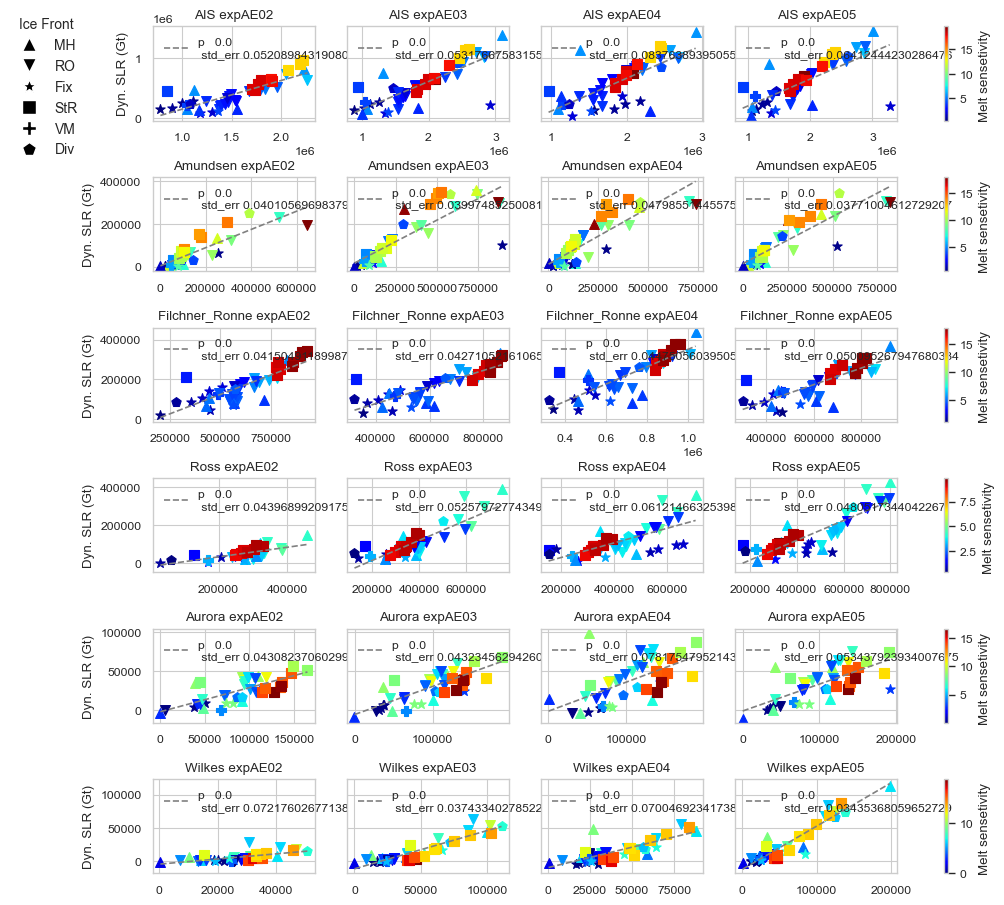

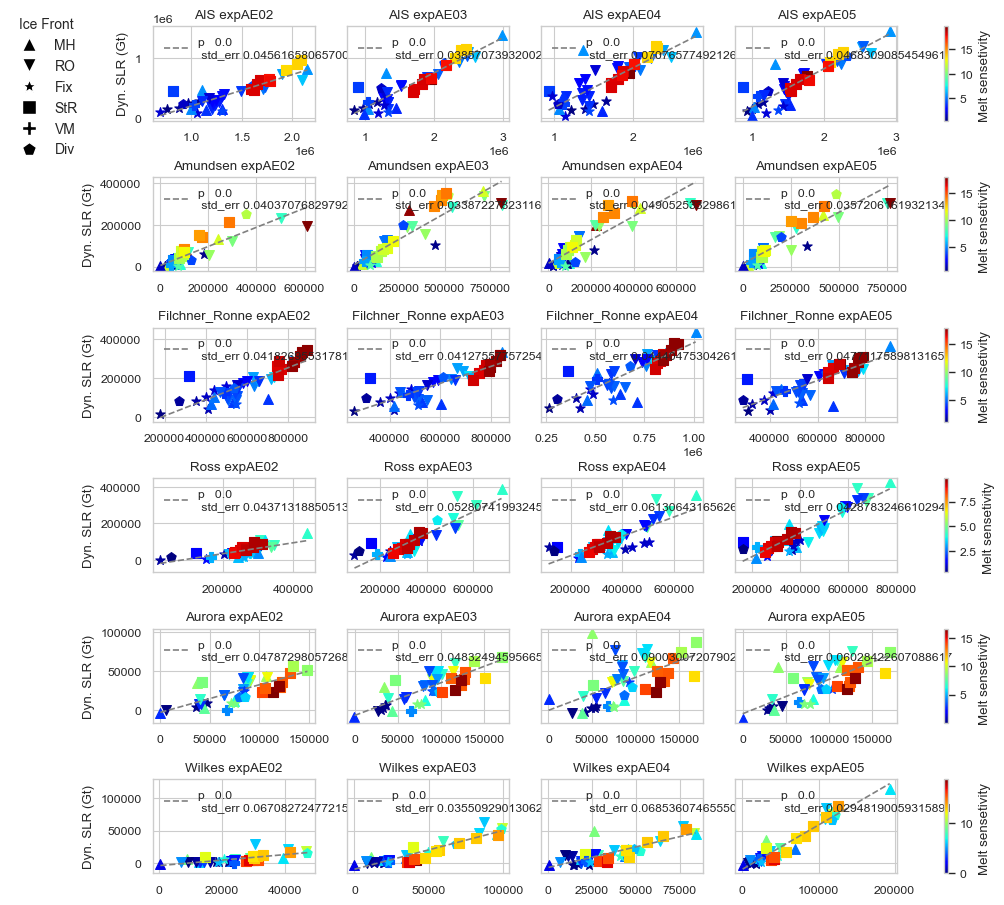

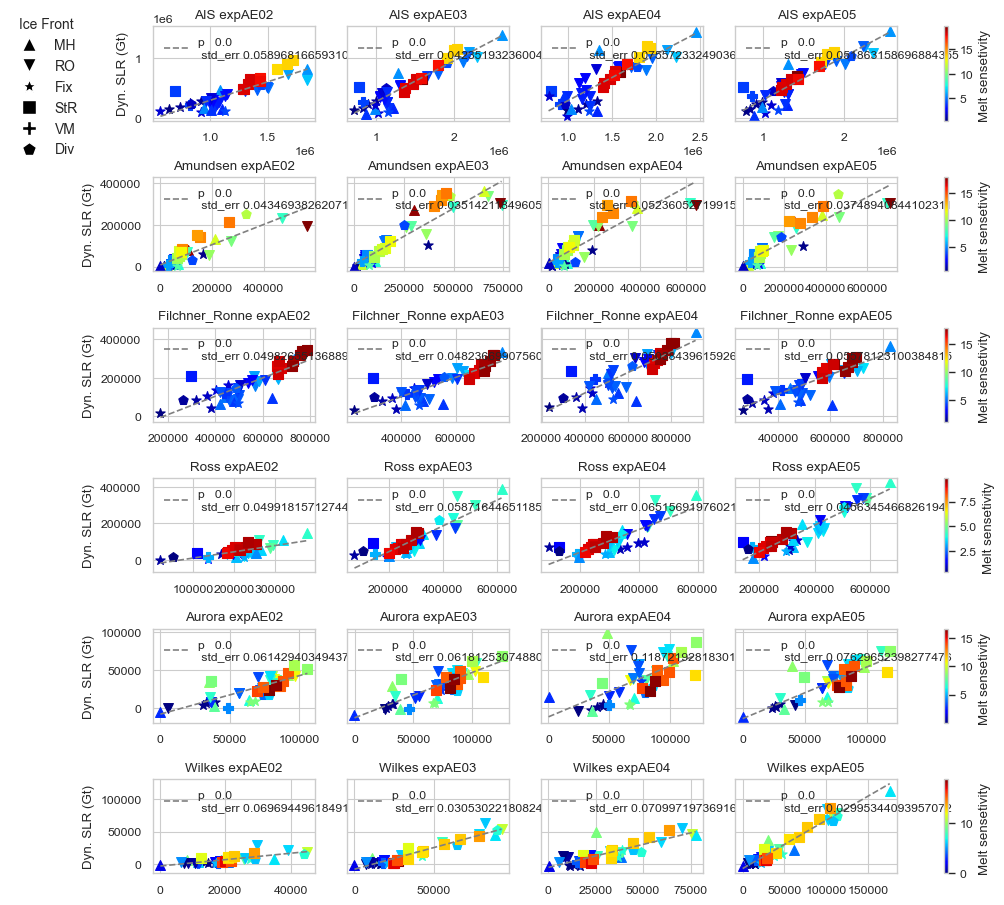

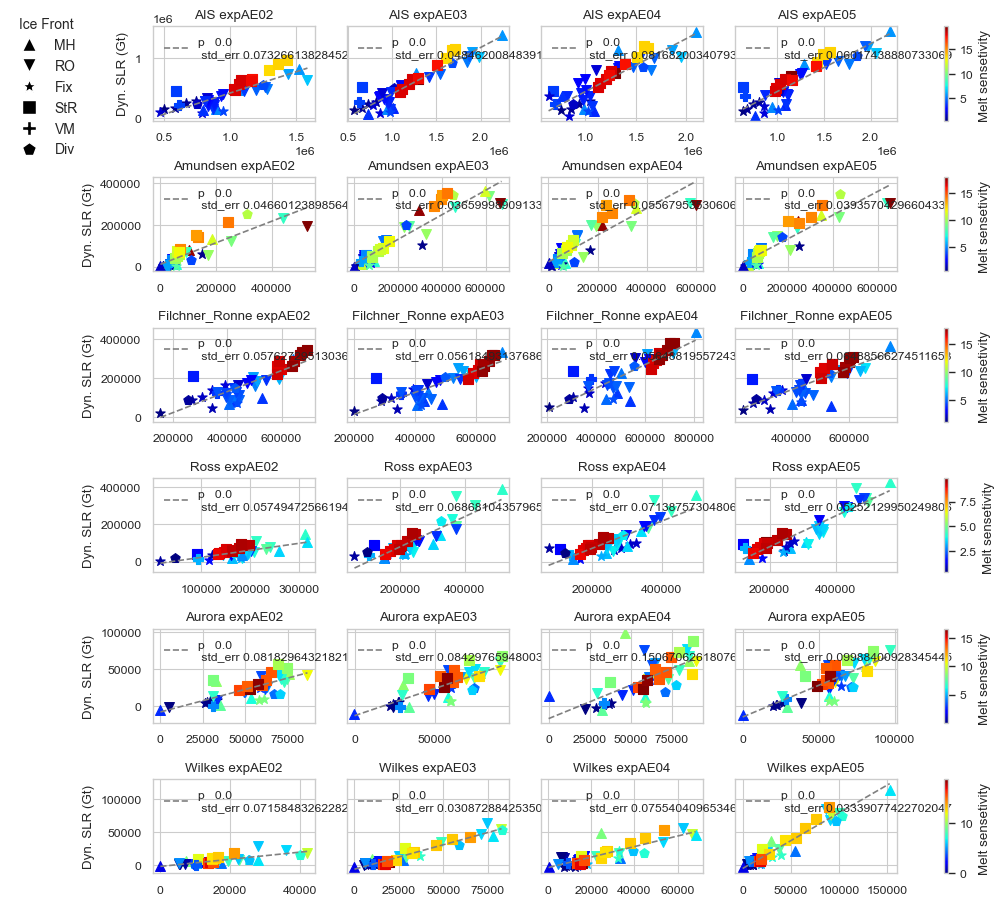

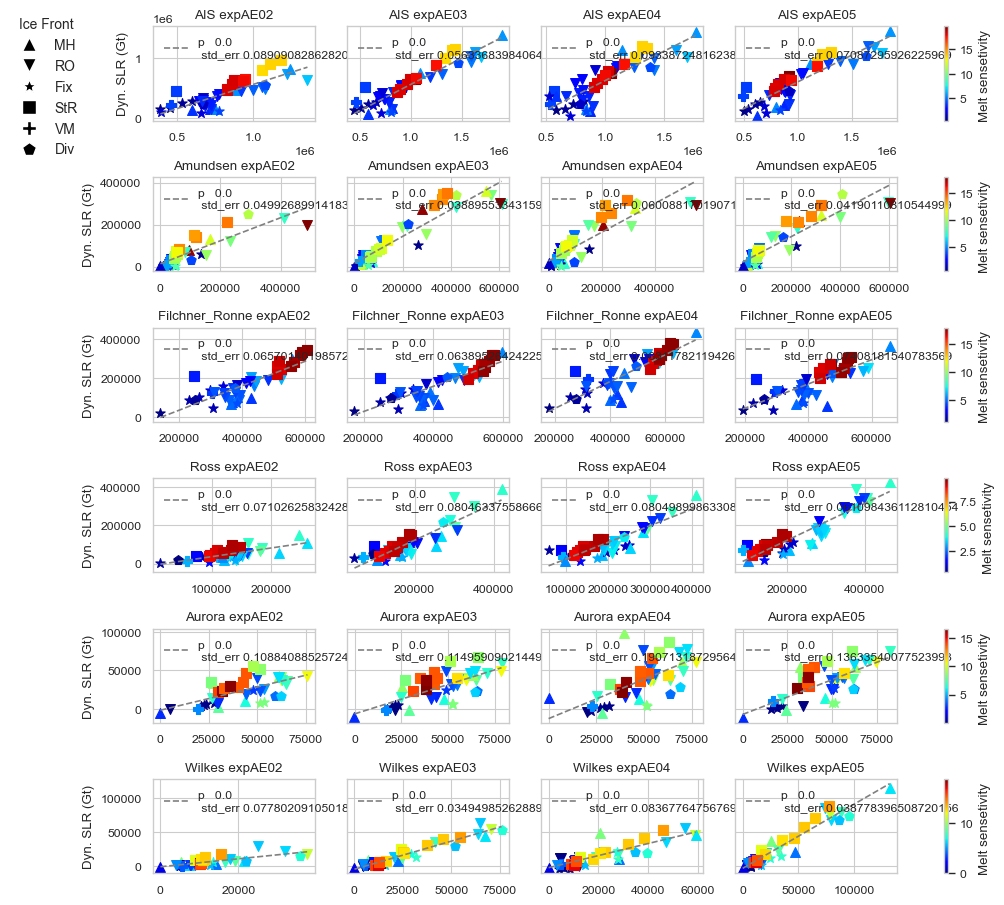

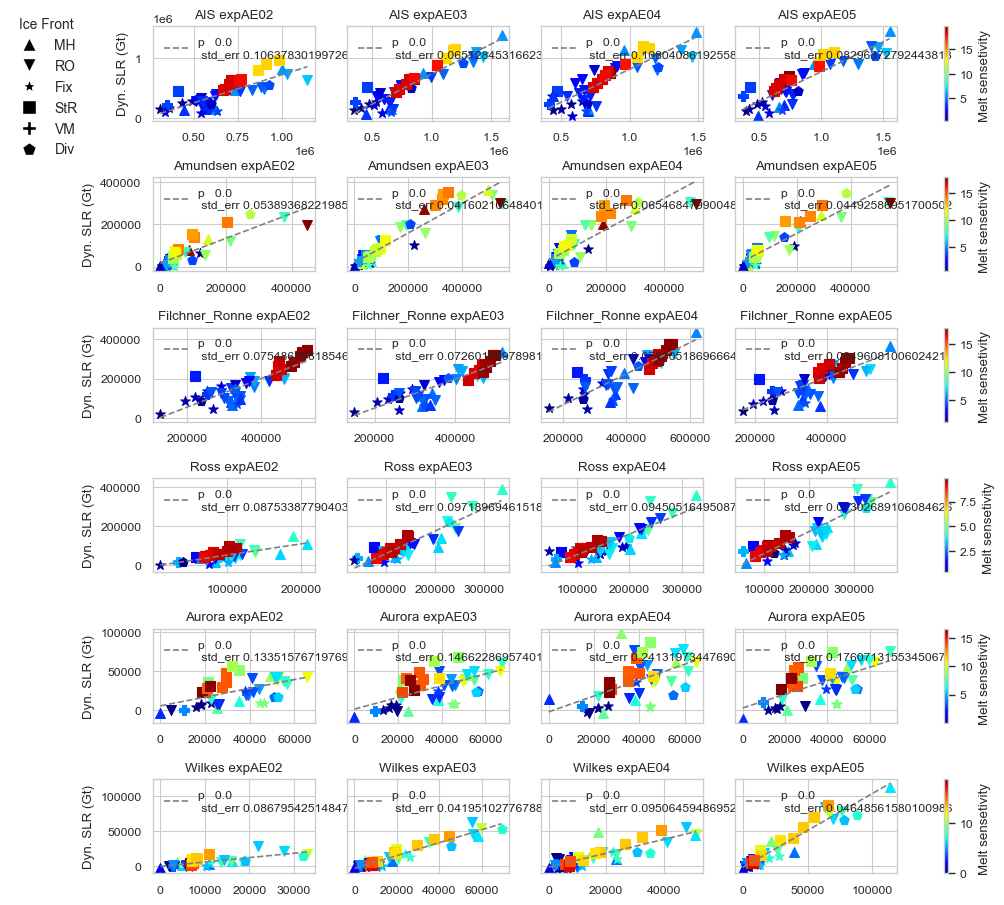

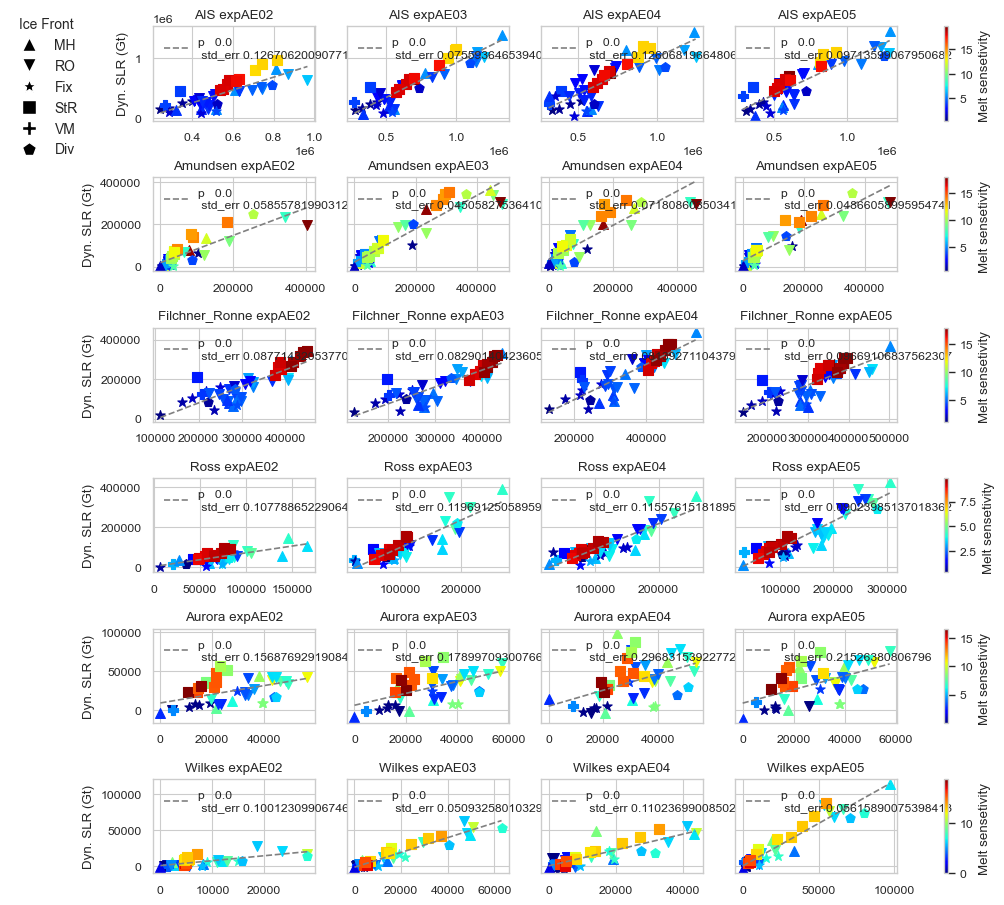

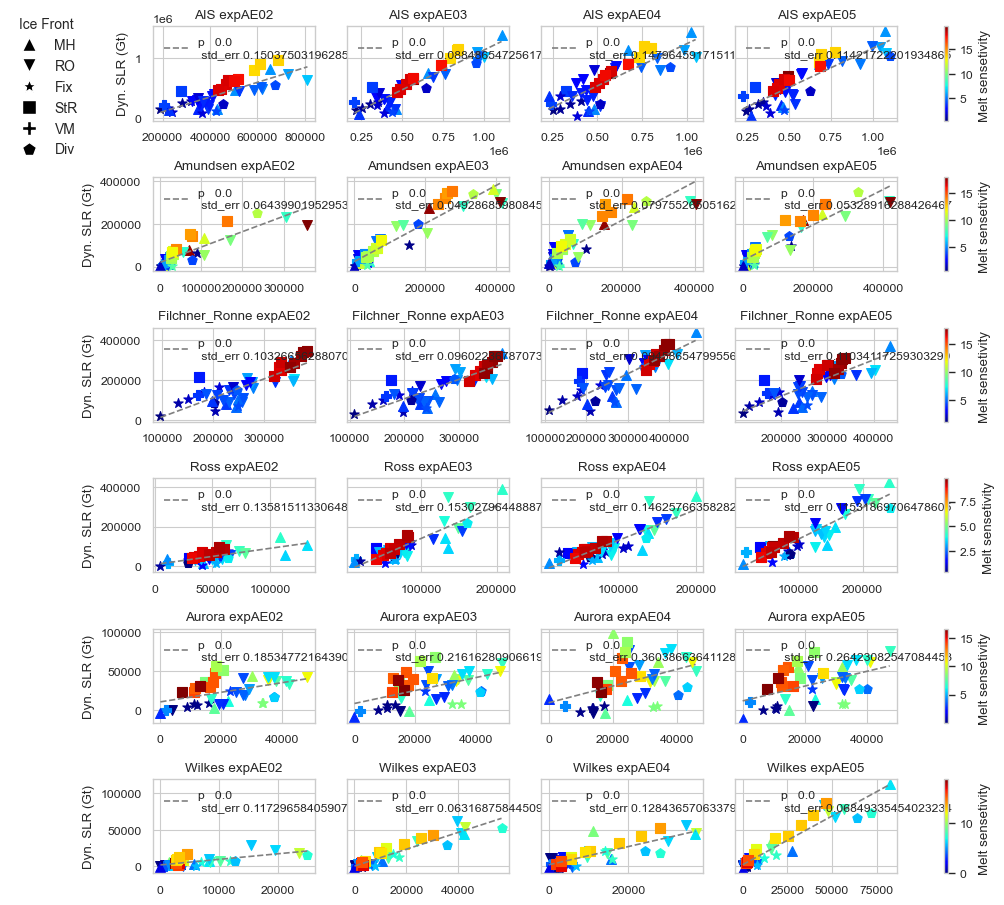

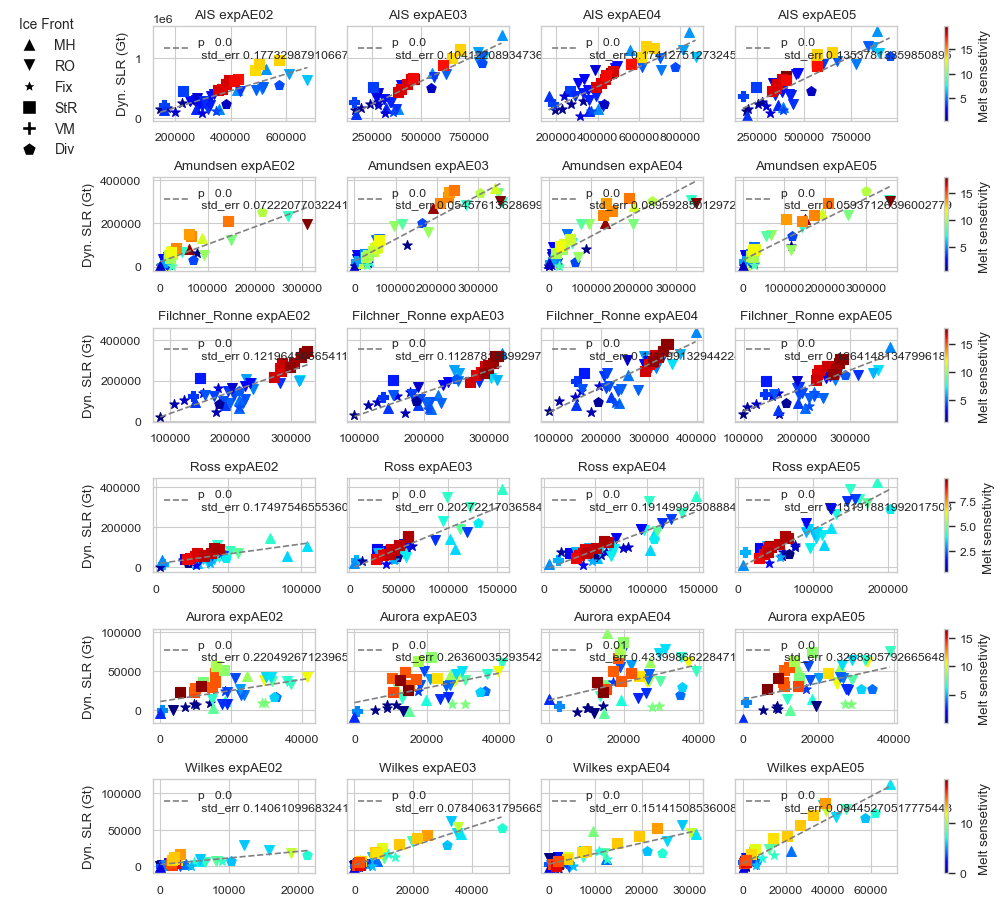

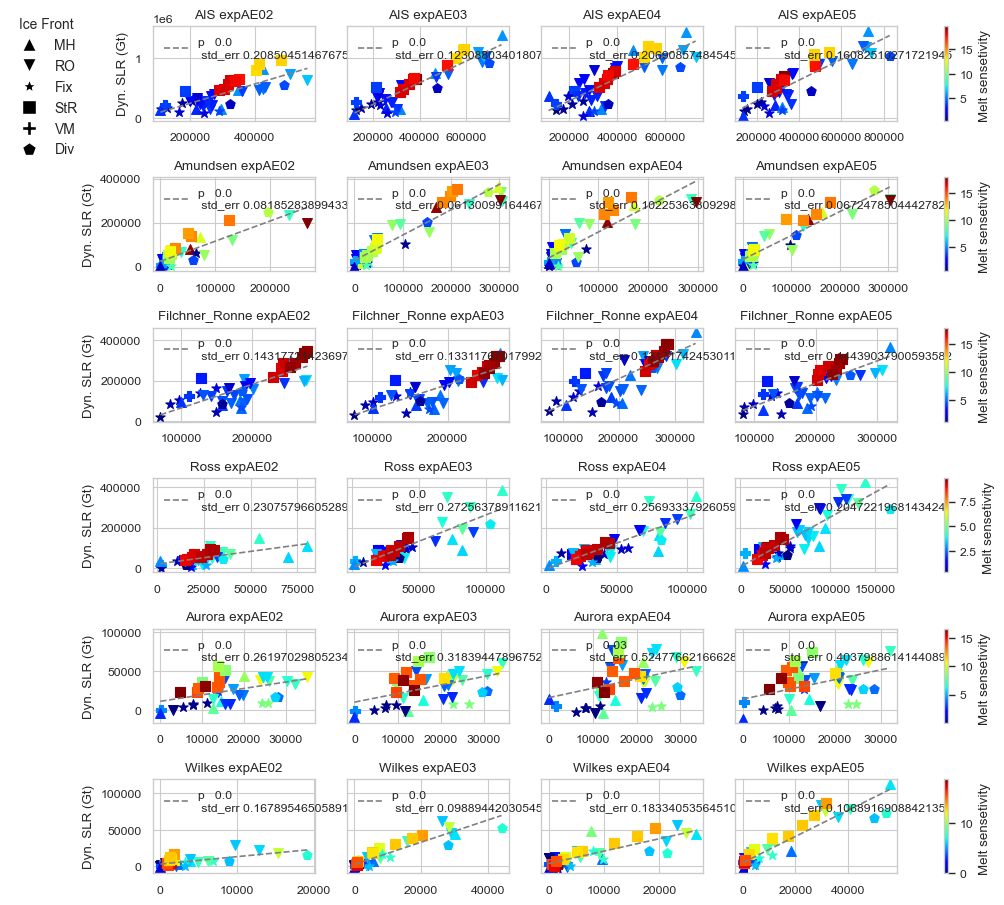

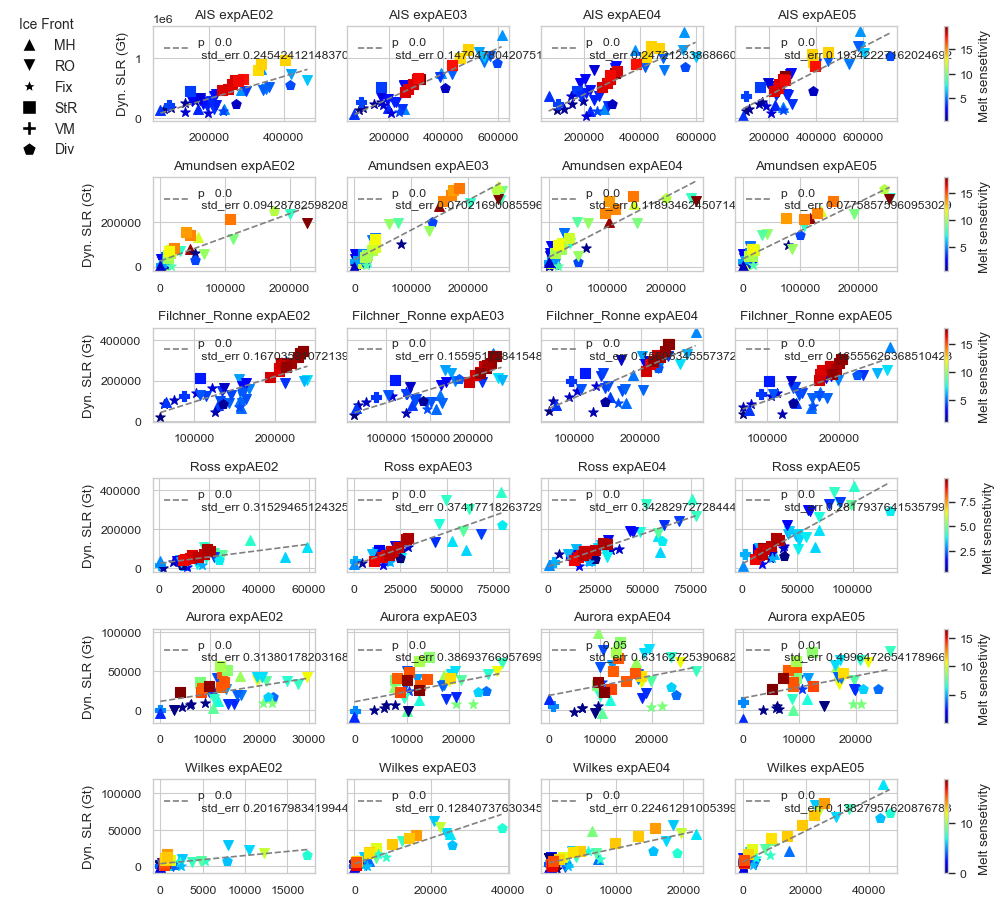

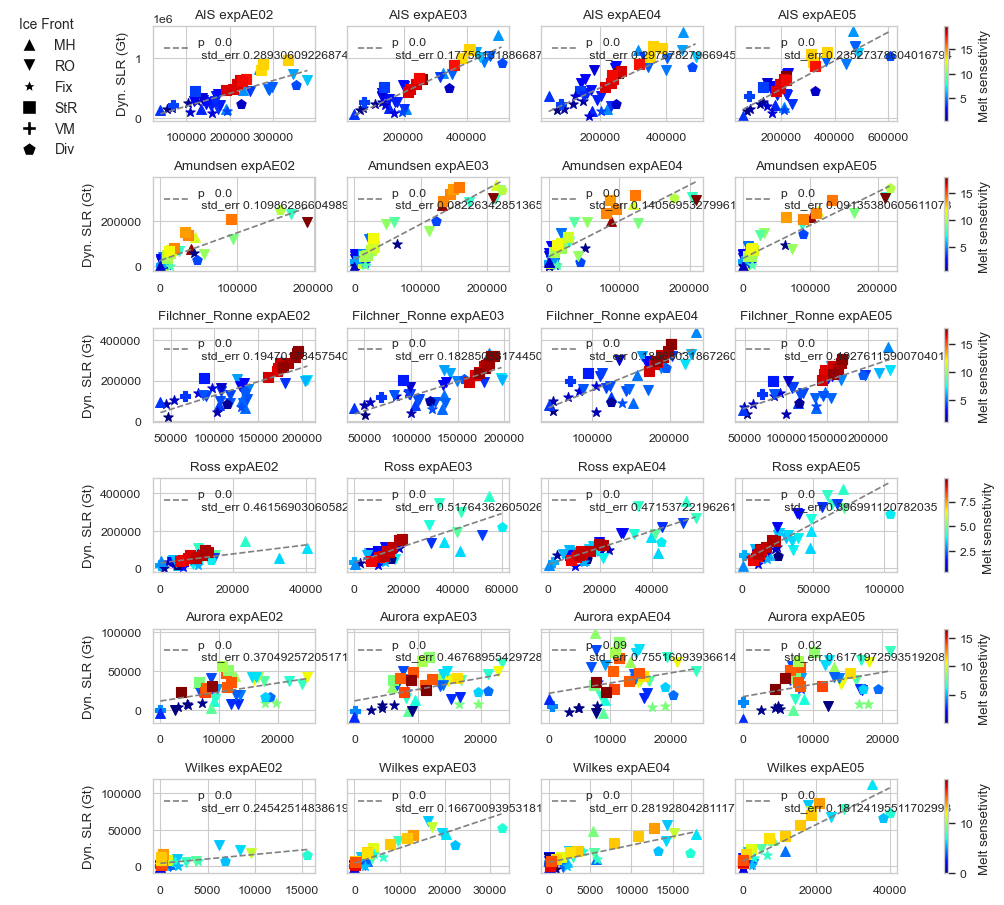

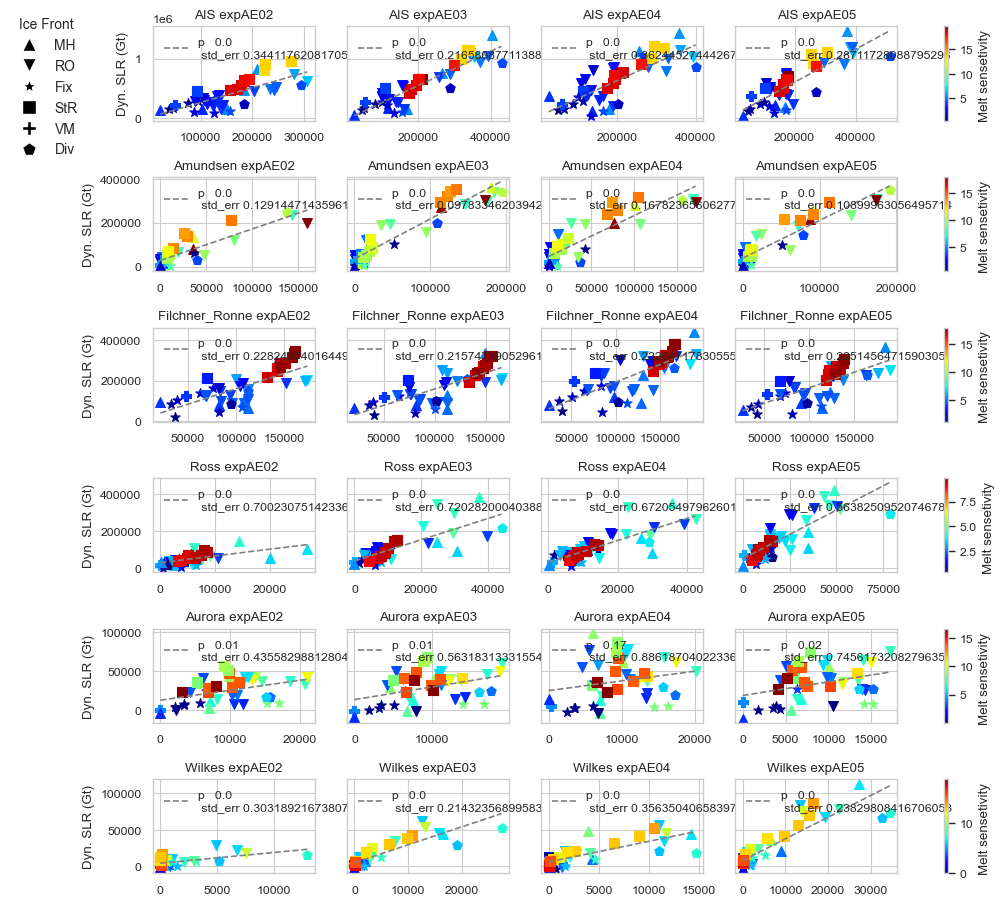

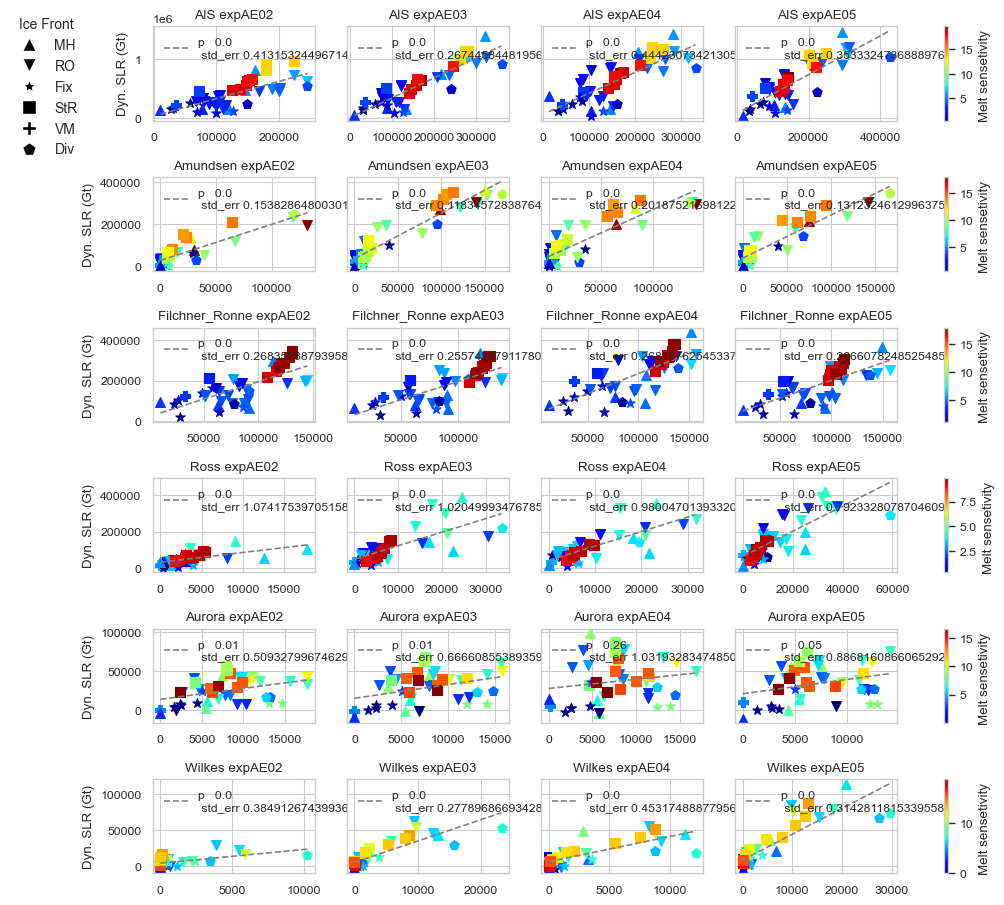

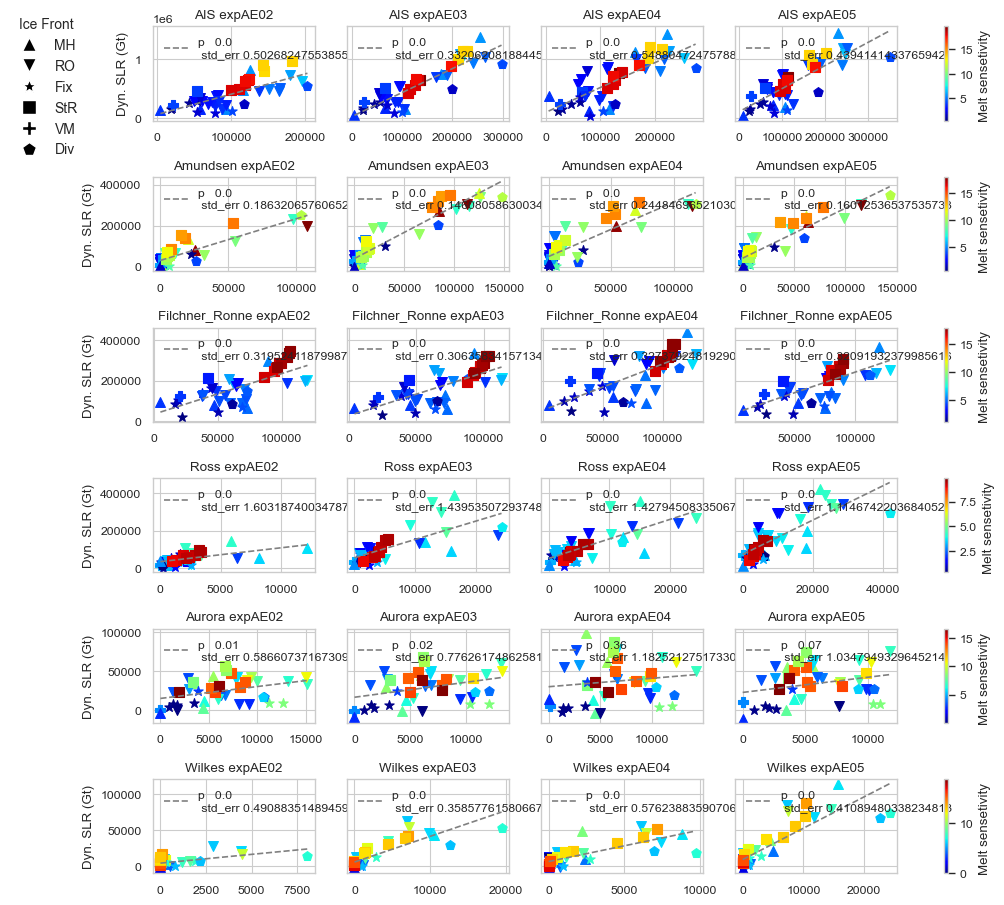

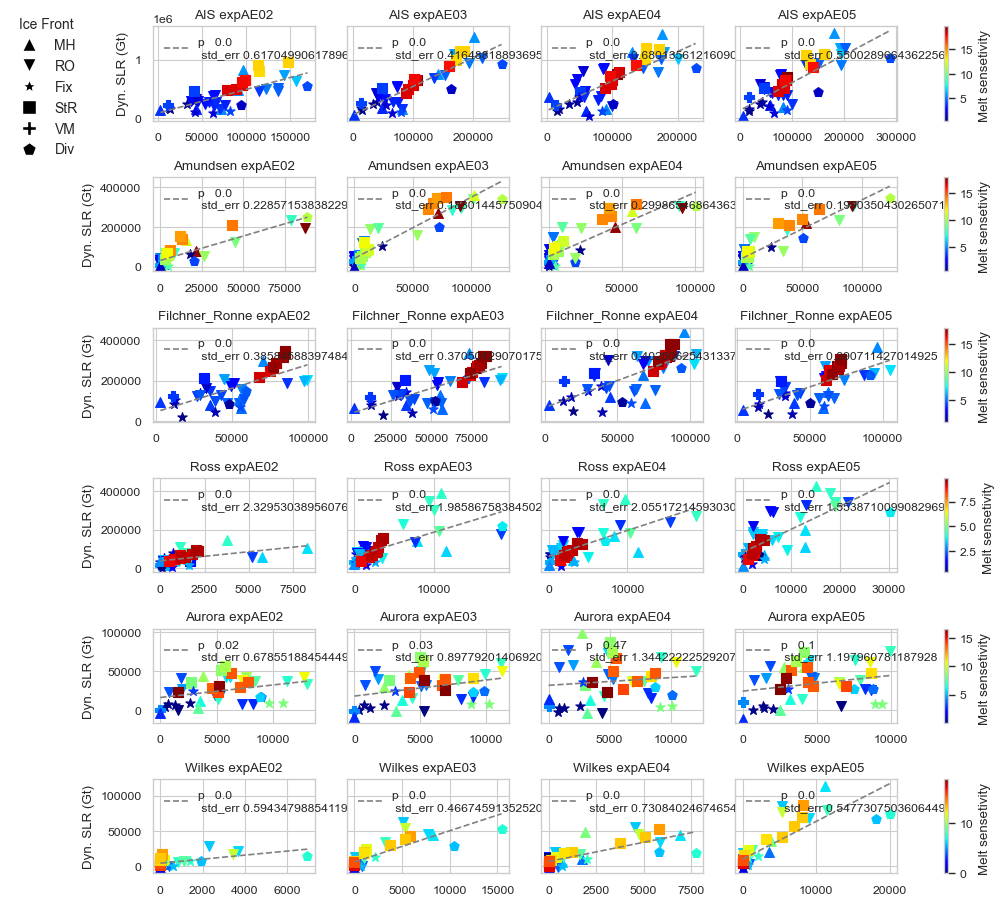

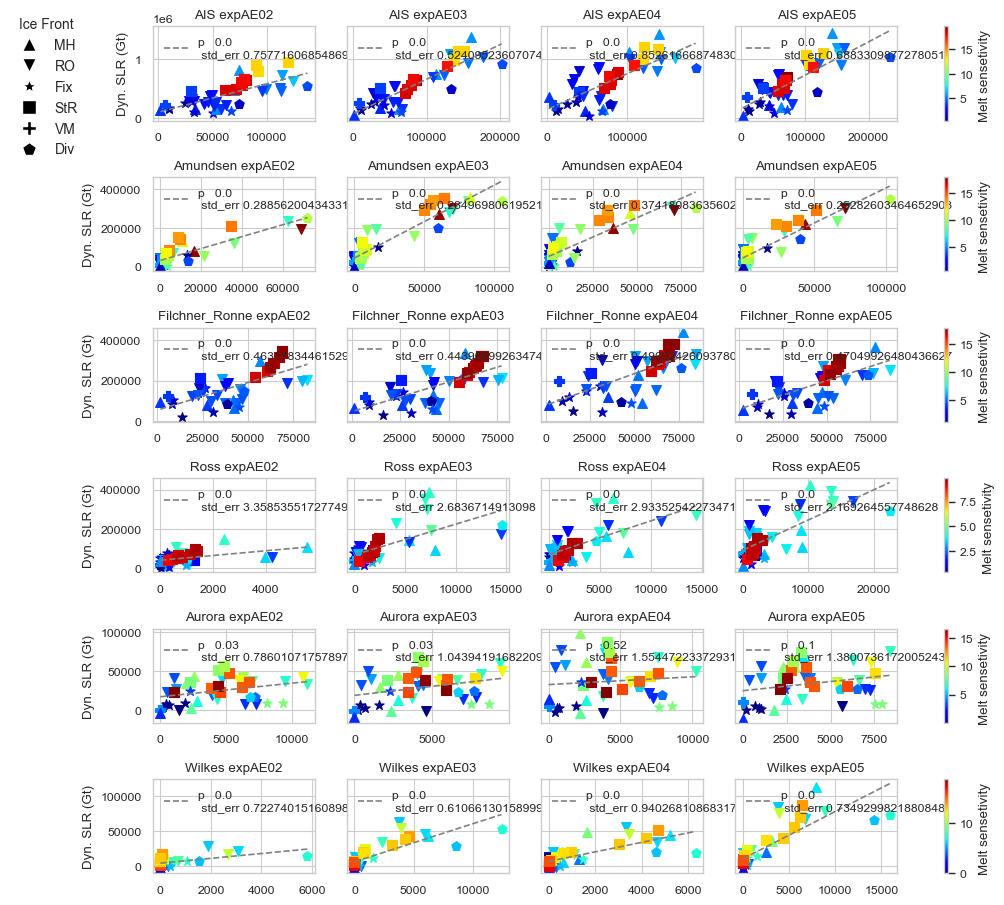

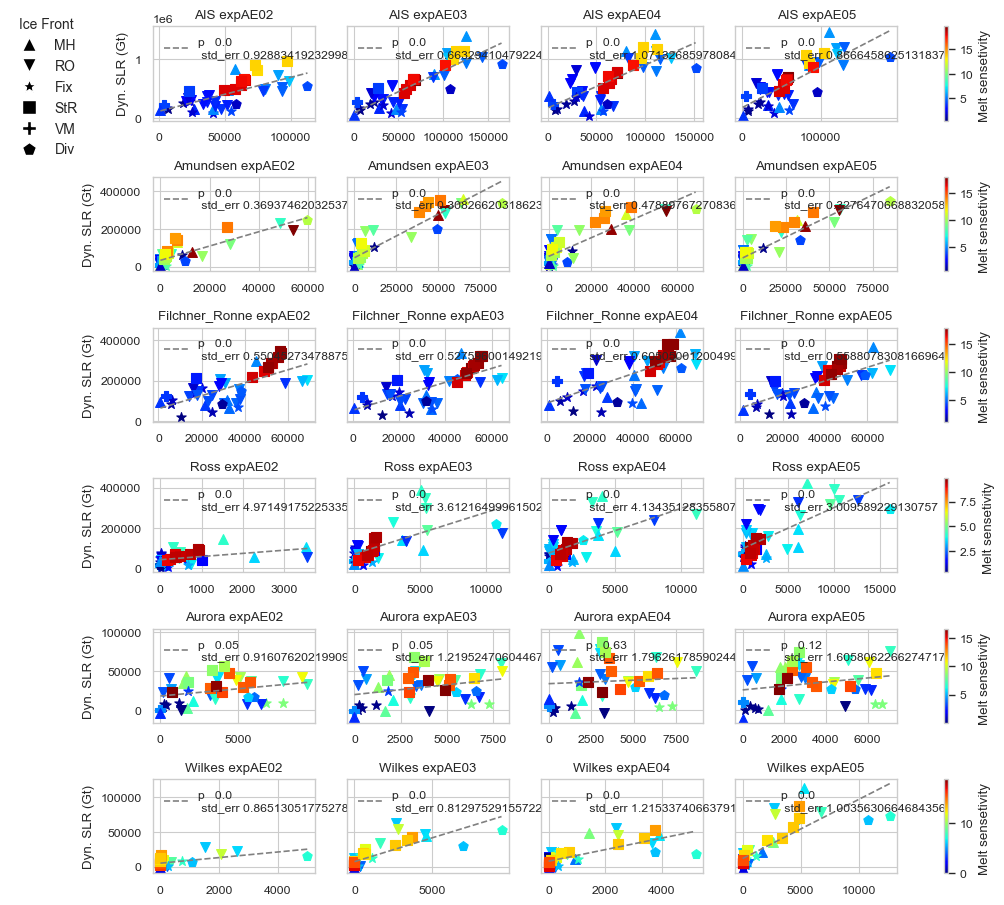

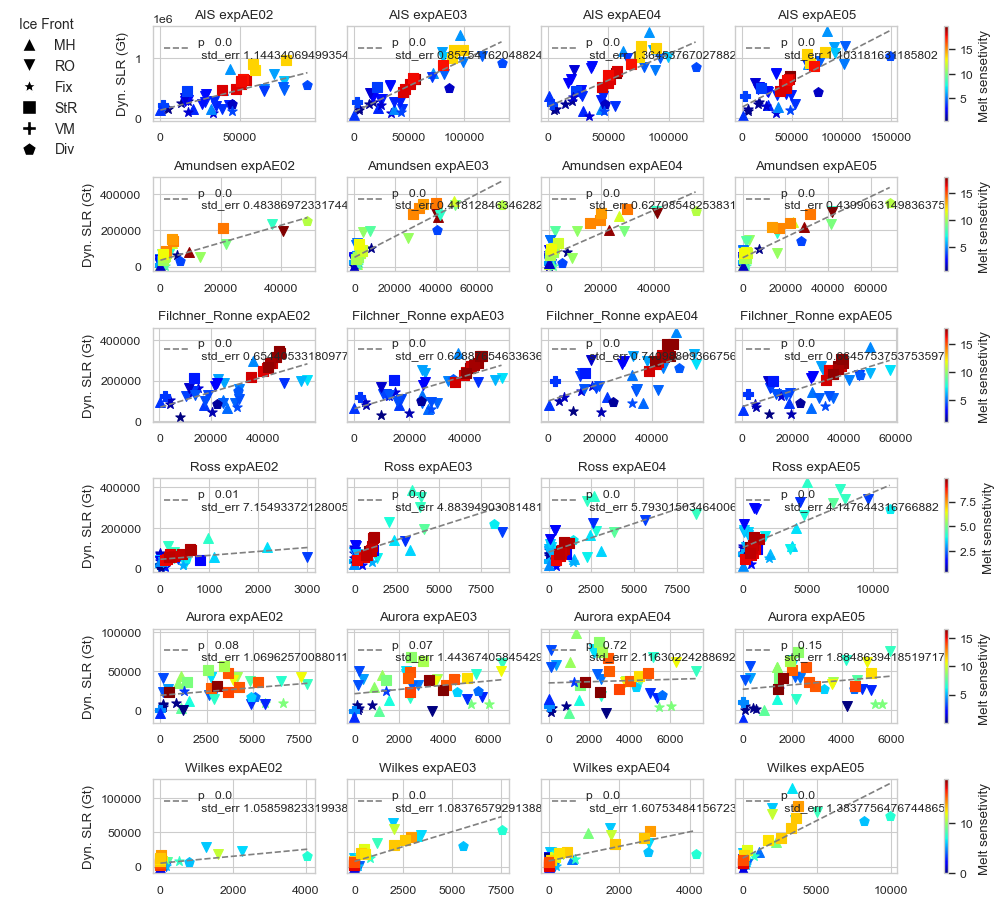

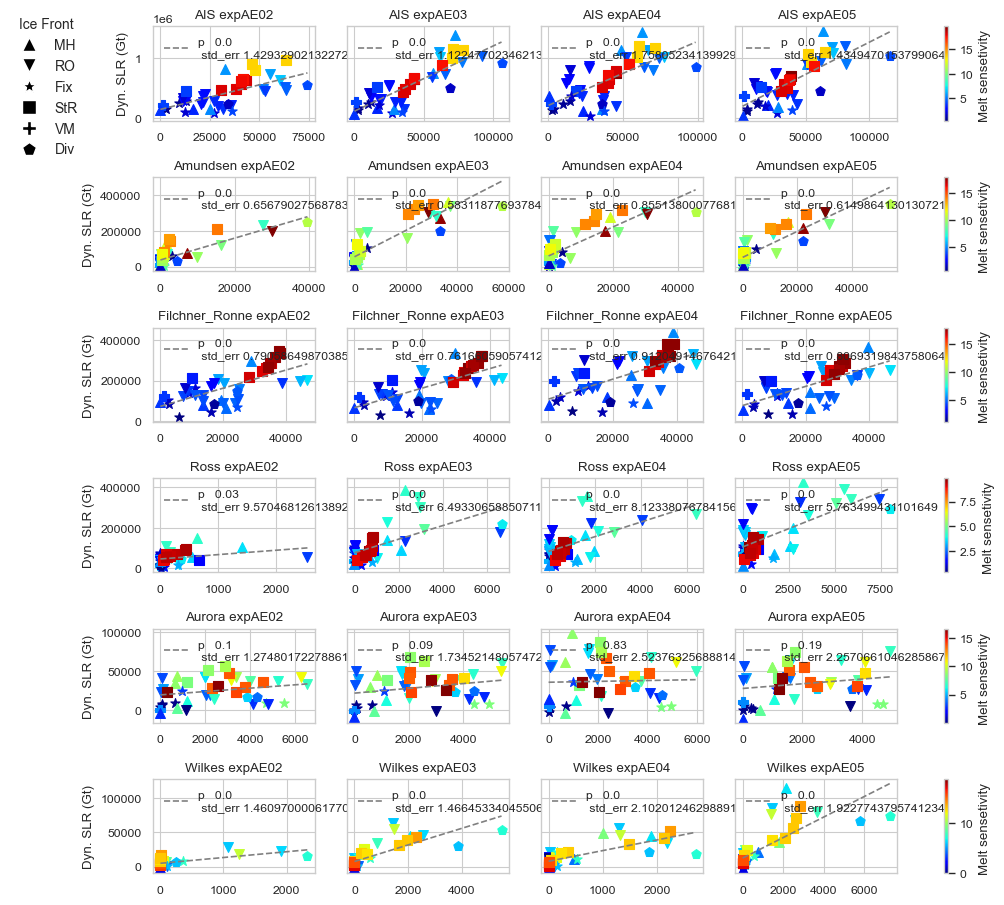

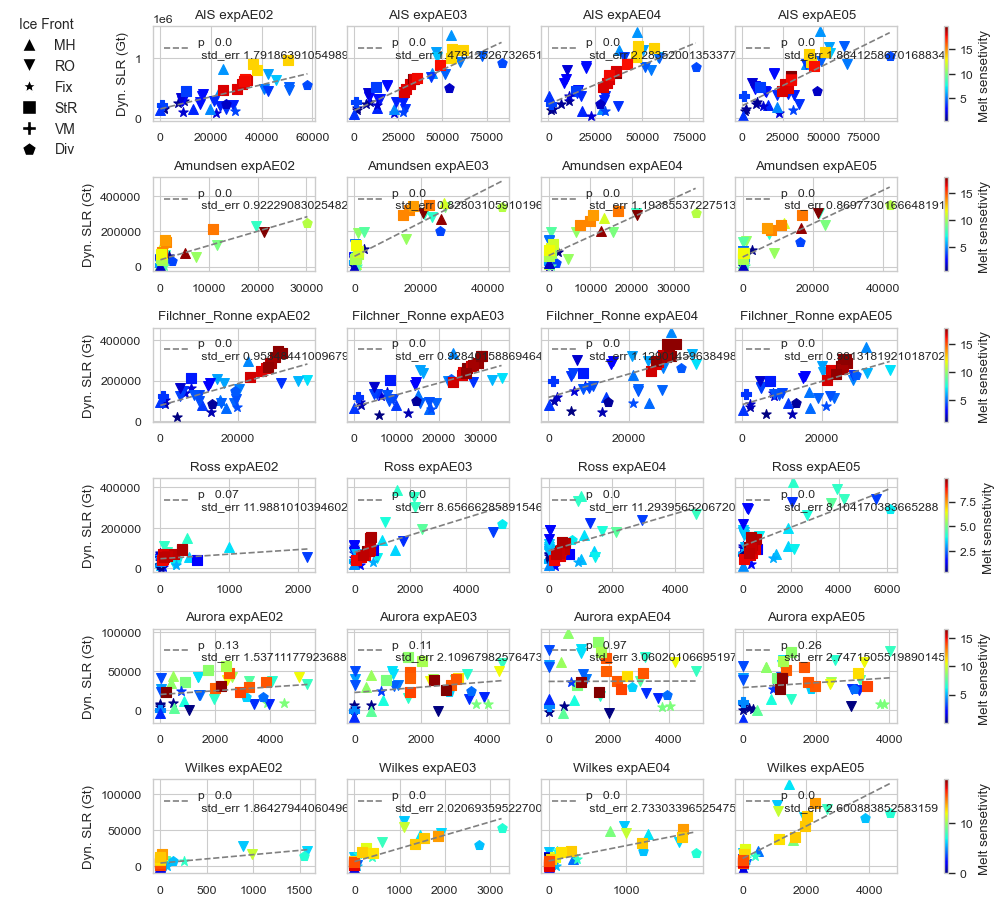

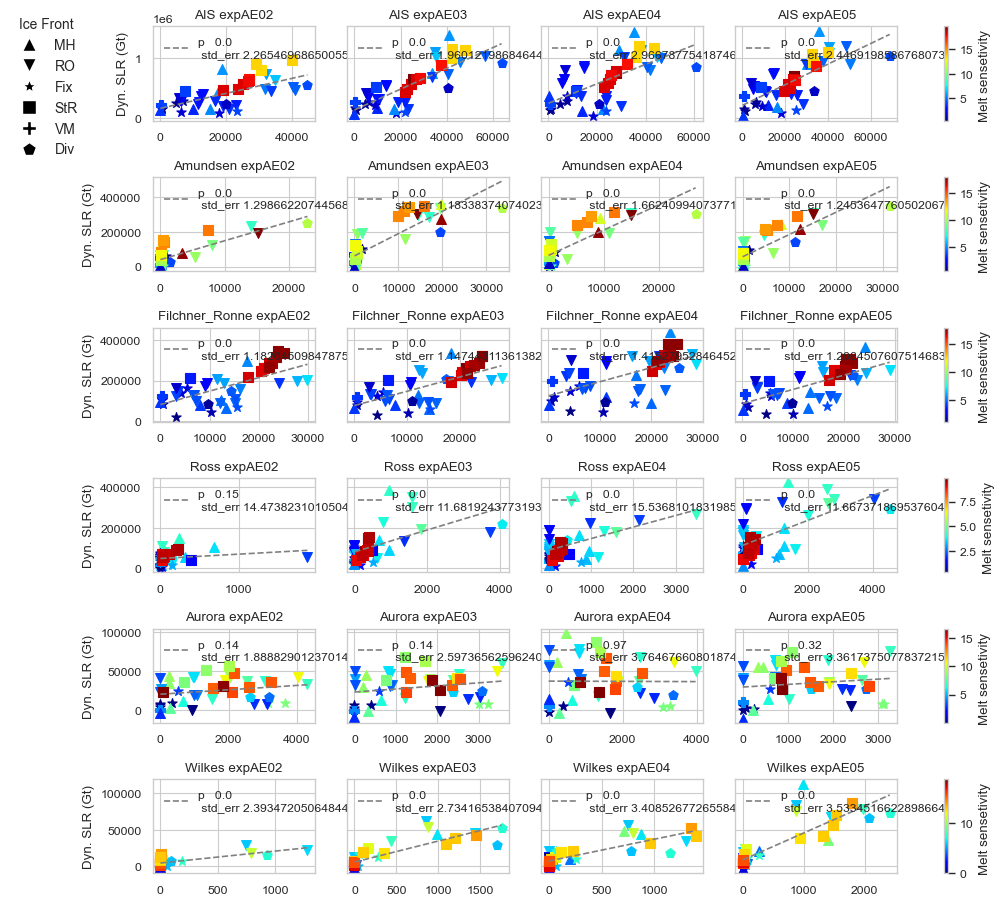

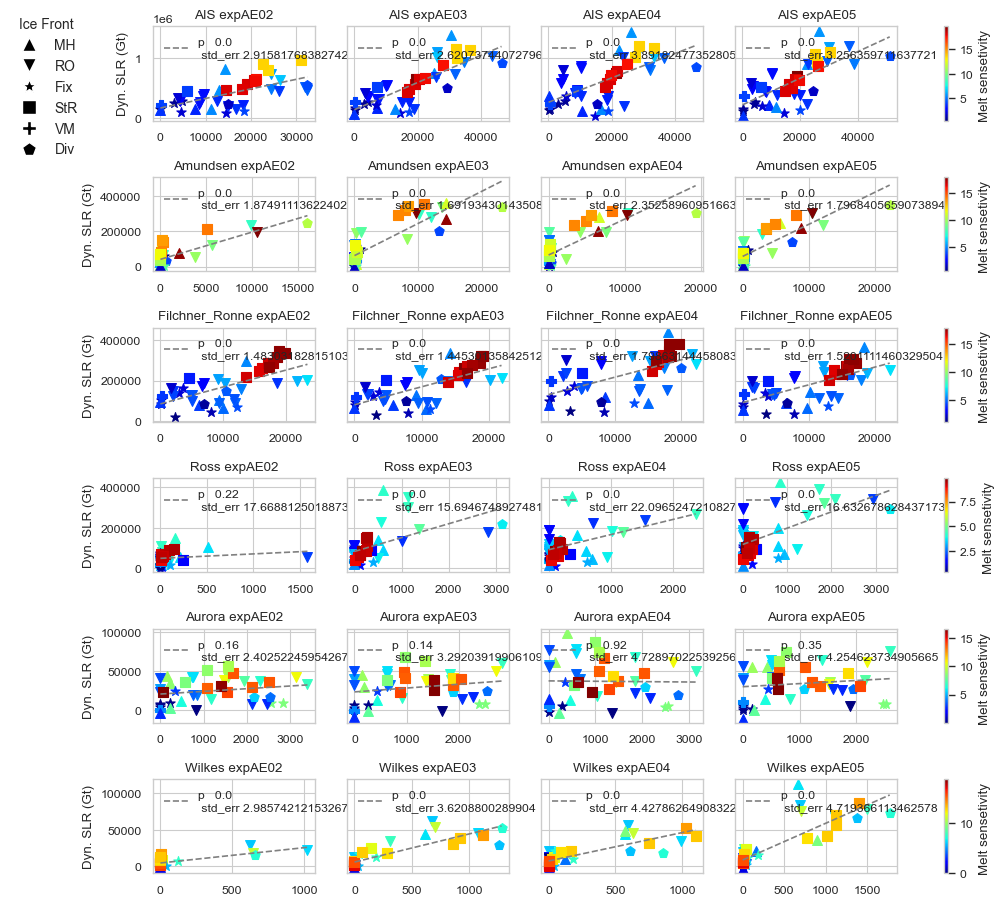

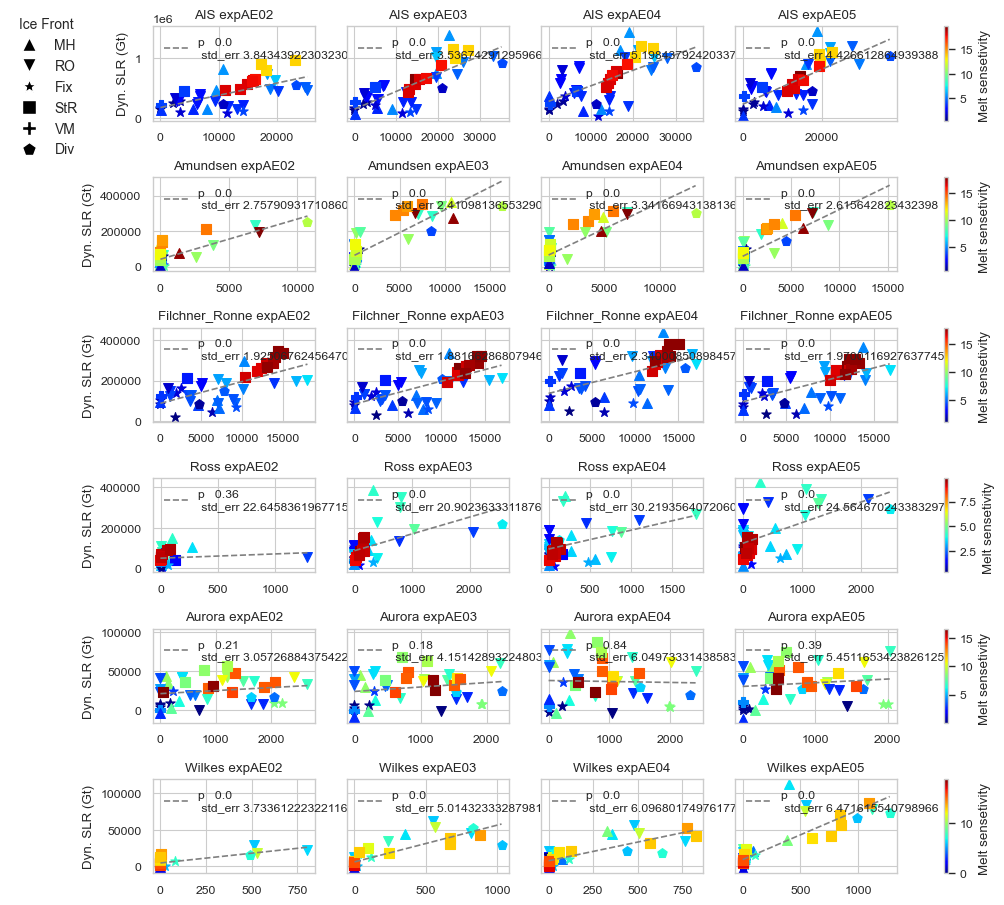

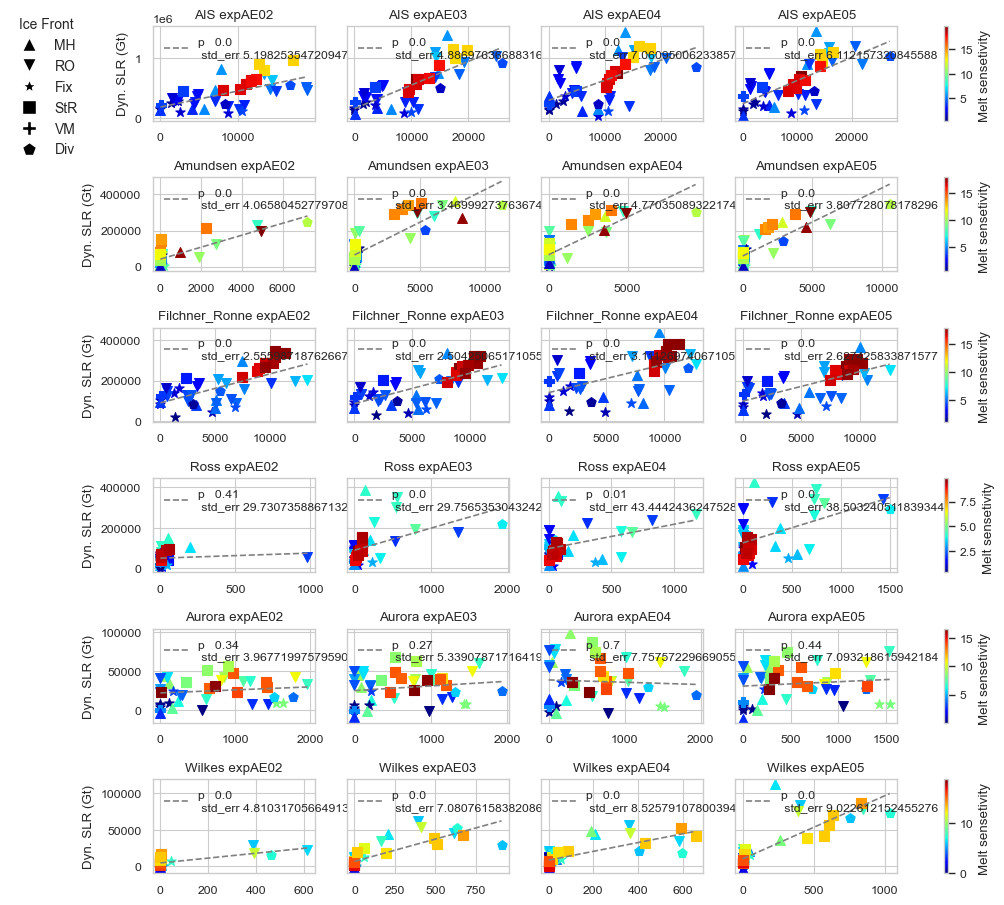

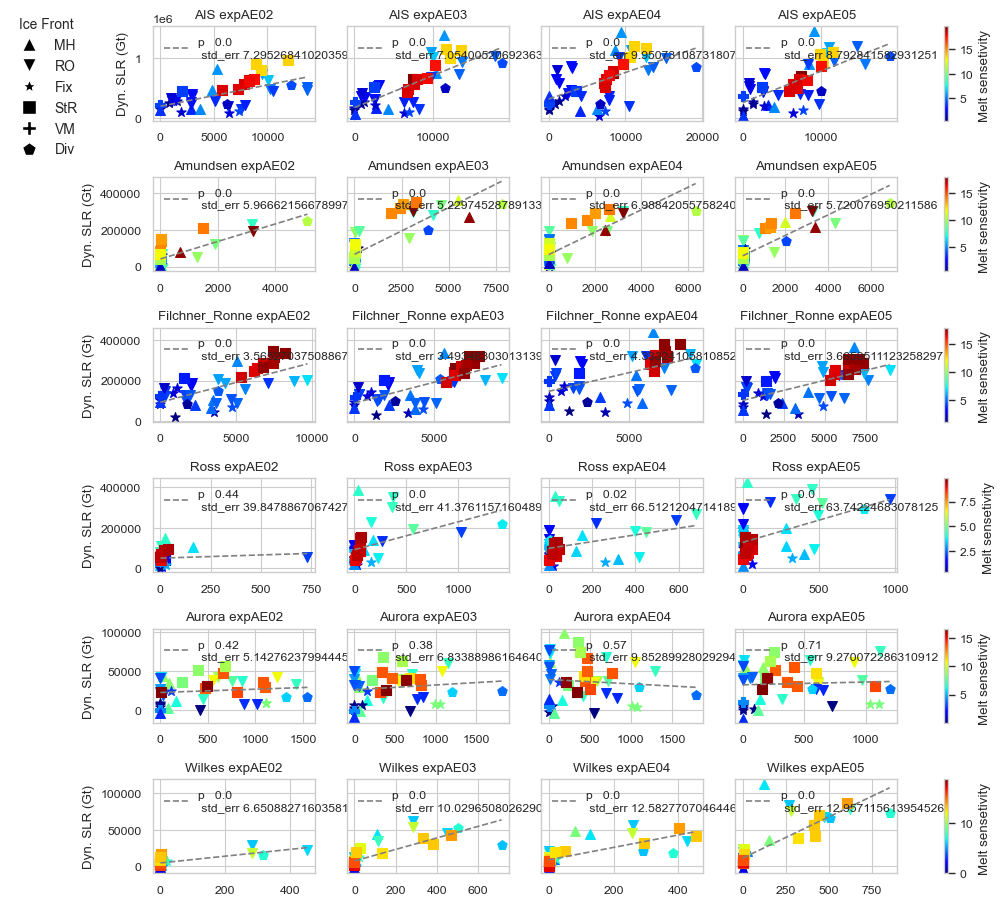

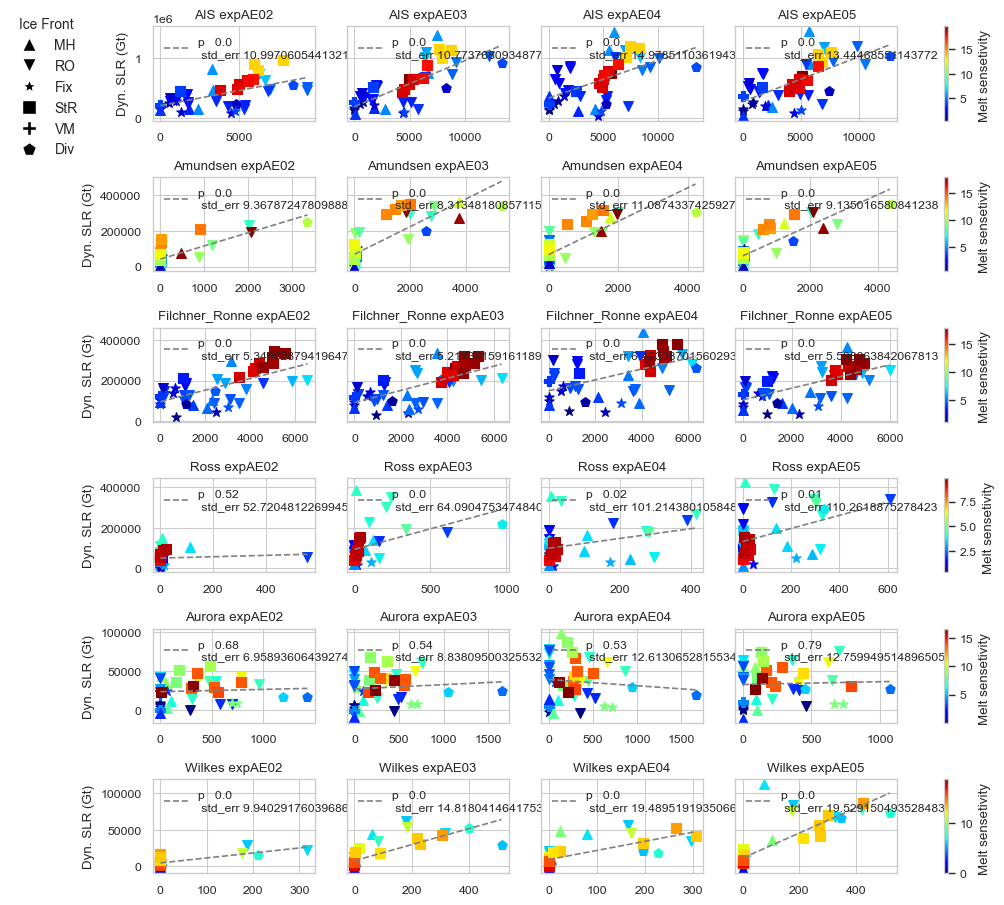

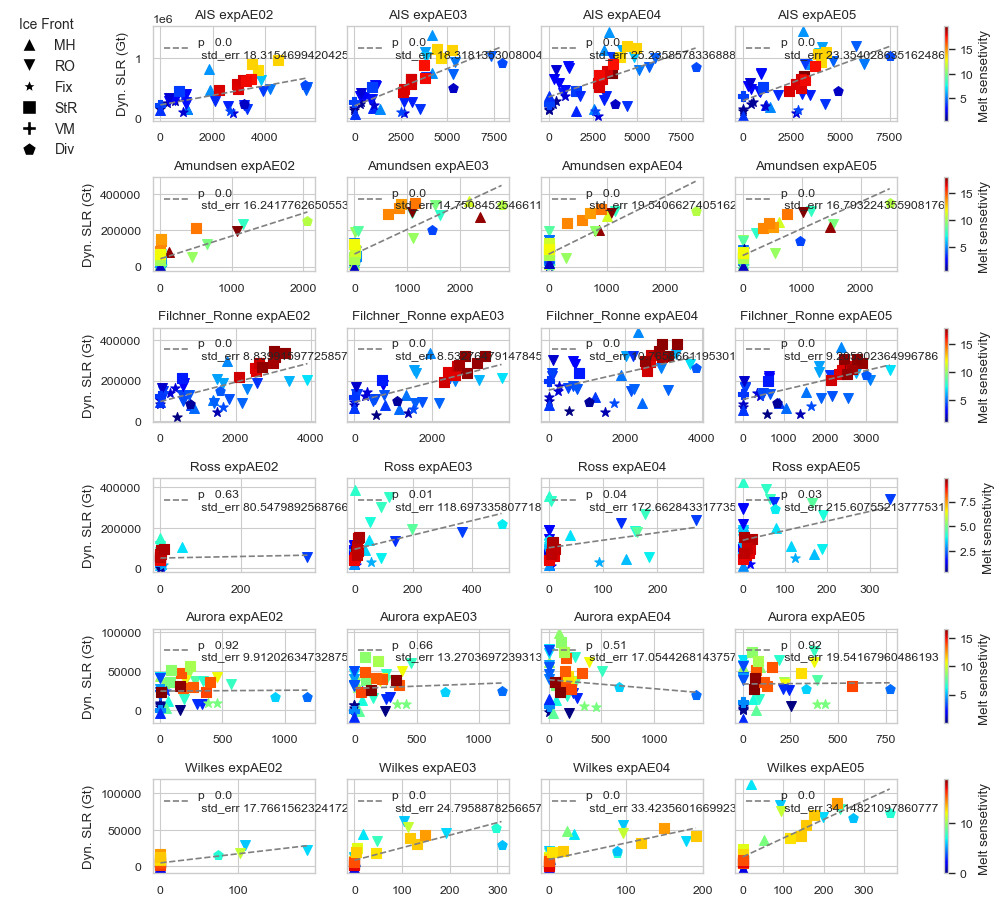

In [41]:
dslr = df_dslr2300
dic_p_depth_all ={}
dic_stderr_depth={}
dic_num_0_depth={}
for depth_i,depth in enumerate(depths[:-2]):
  
    f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,11),sharey='row')
    plt.subplots_adjust(wspace=0.2, hspace=0.6)
    legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                                  markerfacecolor='black', markersize=10)
                       for param, marker in dic_params_scatter.items()]
    dic_p_region={}
    dic_stderr_region ={}
    dic_num_0_region={}
    
    for i,region in enumerate(regions):
    #     ms = df_cumBMB2300_mean[f'{region}']
    #     ms = -1*df_iareagr2300_change[f'{region}']
        ms = df_best[f'melt_sensetivity_{region}']
        #get coloarbar
        norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
        sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
        sm.set_array([])  # Needed for the colorbar
        dic_p_exp ={}
        dic_stderr_exp ={}
        
        dic_num_0={}
        
        for j, exp in enumerate(expnames):
            exp_all =dic_region_cum[region]
            exp_models =exp_all[exp]
            dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
            df_cumBMB2300_exp = df_cumBMB2300[df_cumBMB2300.Experiment == exp].reset_index(drop = True)
            bmb_depth_models = []
            colors = plt.cm.jet(norm(ms))
            ax = ax2[i,j]
            x_all =[]
            y_all =[]
            for k,model in enumerate(models):
               
                if exp == 'expAE02' and model == 'VUW_PISM1_s1':
                    continue
                elif exp == 'expAE05'and model == 'VUW_PISM_s3' and region =='Wilkes':
                    continue
                else:

                    fracbmb_model_all_depths =exp_models[model]
                    frac_depth = fracbmb_model_all_depths[depth_i]

                    yi = dslr_exp[region].values[k]
                    xi = frac_depth*df_cumBMB2300_exp[region].values[k]
    #             scatter = ax.scatter(xi, yi, c=colors[k])
                    scatter = ax.scatter(xi, yi, c=colors[k], marker = marker_model[k],s=50)

                    x_all.append(xi)
                    y_all.append(yi)


                    # Set ylabel for the first column
            slope, intercept, r, p, se = linregress(x_all, y_all)
            x = np.linspace(min(x_all),max(x_all),100)
            

            y_linregress= slope *x+intercept
            ax.plot(x,y_linregress,'--',color = 'gray', label = f'p   {np.round(p,2)} \n std_err {se}' )
            dic_p_exp[exp]=p
            dic_stderr_exp[exp]=se
            
            dic_num_0[exp]=sum(np.asarray(x_all)== 0)/len(x_all)
            ax.set_title(f'{region} {exp}')
            ax.legend(loc=2,frameon = False)


            if j == 0:
                ax2[i, 0].set_ylabel('Dyn. SLR (Gt)')

        # Add a colorbar to each row of plots
        cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
        cbar.set_label(f'Melt sensetivity ')
        dic_p_region[region]=dic_p_exp
        dic_stderr_region[region]=dic_stderr_exp
        dic_num_0_region[region]=dic_num_0
        
        
    #         ax.scatter(dachange_exp[region],dslr_exp[region])
    f.legend(handles=legend_elements, title='Ice Front', loc='upper left', bbox_to_anchor=(0., 0.9), fontsize=10, title_fontsize=10,frameon=False)
        #     ax[i].plot(Models.index,y)  
    depth_n =abs(depth +30)
    f.savefig(f'figs/dynSLR_BMB_cum_depth/jepg/dynslr_cum_BMB_until_{depth_n}m.jpeg')  
    f.savefig(f'figs/dynSLR_BMB_cum_depth/pdf/dynslr_cum_BMB_until_{depth_n}m.pdf') 
    dic_p_depth_all[depth]=dic_p_region
    dic_stderr_depth[depth]=dic_stderr_region
    dic_num_0_depth[depth]=dic_num_0_region
    
    
    

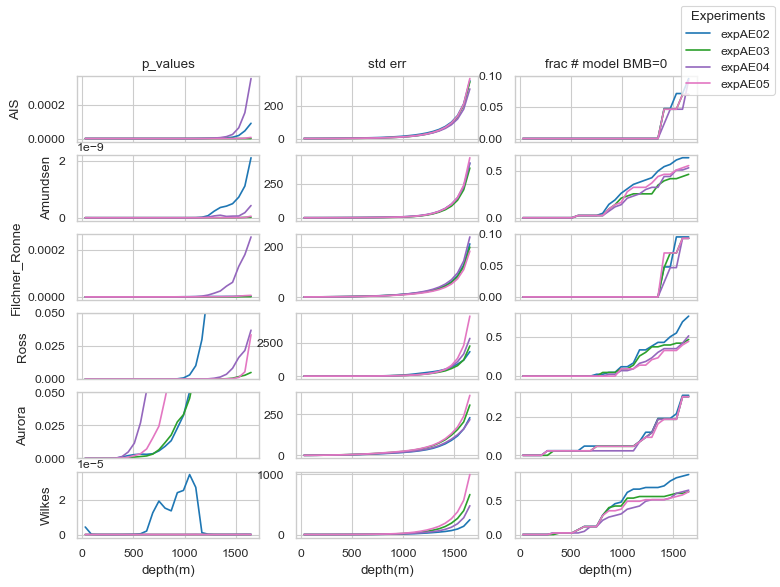

In [42]:
 f,ax = plt.subplots(len(regions),3,figsize = (8,6),sharex = True)
colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
for i,region in enumerate(regions):
     for j, exp in enumerate(expnames):
            p_depths=[]
            stderr_depths=[]
            n_0_depths =[]
            
            for depth_i,depth in enumerate(depths[:-2]):
                p_depths.append(dic_p_depth_all[depth][region][exp])
                stderr_depths.append(dic_stderr_depth[depth][region][exp])
                n_0_depths.append(dic_num_0_depth[depth][region][exp])
            ax[i,0].plot(-1*depths[:-2],p_depths,color = colors[j],label = f'{exp}')
            if np.asarray(p_depths).max()>0.05:
                ax[i,0].set_ylim([0,0.05])
            
            ax[i,1].plot(-1*depths[:-2],stderr_depths/stderr_depths[0],color = colors[j]) 
            ax[i,2].plot(-1*depths[:-2],n_0_depths,color = colors[j]) 
            ax[i,0].set_ylabel(f'{region}',rotation = 90)
            ax[0,0].set_title(f'p_values')
            ax[0,1].set_title(f'std err')
            ax[0,2].set_title(f'frac # model BMB=0')
    
ax[i,0].set_xlabel(f'depth(m)')
ax[i,1].set_xlabel(f'depth(m)')
ax[i,2].set_xlabel(f'depth(m)')
        
            
#             ax[5,0].set_ylim([0,0.05])
            
            
            
handles, labels = ax[0, 0].get_legend_handles_labels()
f.legend(handles, labels, loc='upper right', title='Experiments')

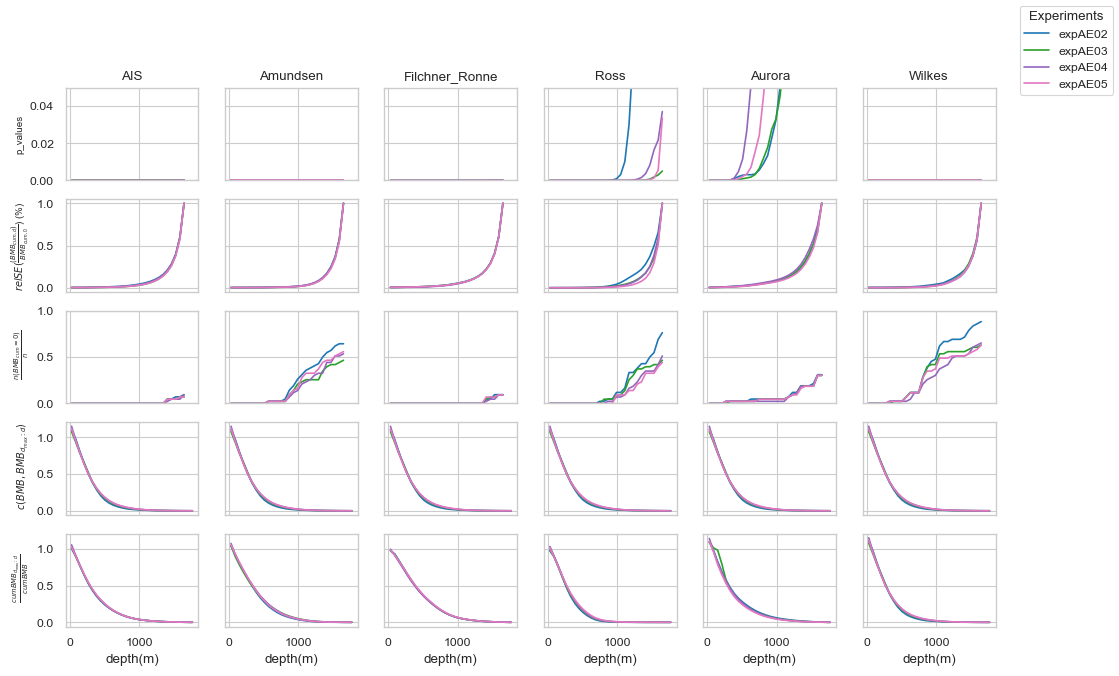

In [43]:
f,ax = plt.subplots(5,len(regions),figsize = (12,7),sharex = True,sharey ='row')
colors = ['#1f77b4',
    '#2ca02c',
    '#9467bd',
    '#e377c2']
for i,region in enumerate(regions):
     for j, exp in enumerate(expnames):
            p_depths=[]
            stderr_depths=[]
            n_0_depths =[]
            
            for depth_i,depth in enumerate(depths[:-2]):
                p_depths.append(dic_p_depth_all[depth][region][exp])
                stderr_depths.append(dic_stderr_depth[depth][region][exp])
                n_0_depths.append(dic_num_0_depth[depth][region][exp])
            ax[0,i].plot(-1*depths[:-2],p_depths,color = colors[j],label = f'{exp}')
#             if np.asarray(p_depths).max()>0.05:
            ax[2,0].set_ylim([0,1])
            
            ax[1,i].plot(-1*depths[:-2],stderr_depths/stderr_depths[-1],color = colors[j]) 
            ax[2,i].plot(-1*depths[:-2],n_0_depths,color = colors[j]) 
            ax[3,i].plot(-1*depths,corr_allmdoels[region][exp],color = colors[j]) 
            ax[4,i].plot(-1*depths,cum_allmdoels[region][exp],color = colors[j]) 
            ax[0,0].set_ylim([0.0,0.05])

            
            fs = 7
#             ax[0,i].set_ylabel(f'{region}',rotation = 90)
            ax[0,0].set_ylabel(f'p_values',fontsize =fs)
            ax[1,0].set_ylabel('$ rel SE(\\frac{(BMB_{cum,d})}{BMB_{cum,0}}$) (%)',fontsize =fs)
            ax[2,0].set_ylabel('  $ \\frac{n(BMB_{cum}=0)}{n }$',fontsize =fs)
            ax[3,0].set_ylabel('  $ c(BMB,BMB_{d_{max}:d})$',fontsize =fs)
            ax[4,0].set_ylabel('  $ \\frac{cumBMB_{d_{max}:d}}{cumBMB} }$',fontsize =fs)
            
            
            ax[0,i].set_title(f'{region}')
            ax[-1,i].set_xlabel(f'depth(m)')

       
            
            
handles, labels = ax[0, 0].get_legend_handles_labels()
f.legend(handles, labels, loc='upper right', title='Experiments')
f.savefig('figs/SI/MMM_BMB_dmin_d_vs_BMB.jpeg')